# Laboratorio 7 — Gradient descent desde cero

La solución de mínimos cuadrados por ecuaciones normales ya es conocida: se despeja y se
obtiene el resultado exacto. Este laboratorio construye **el otro camino**, el que sirve
para todos los modelos que no tienen fórmula que despejar —empezando por la logistic
regression, que no la tiene.

Lo que se implementa:

1. La **loss** y su gradiente.
2. **Batch gradient descent**, verificado contra la solución cerrada.
3. El efecto del **learning rate**, leído en la curva de loss.
4. El efecto del **feature scaling**, que es el resultado central.
5. Las variantes **SGD** y de **mini-batches**.
6. El contraste con `SGDRegressor` de `scikit-learn`.
7. **El mismo motor sobre logistic regression**, cambiando una sola función.

Hay **nueve ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar.

> **Vocabulario.** Los nombres de los conceptos van en inglés, que es la forma en que
> aparecen en la documentación y en el código de las bibliotecas: *gradient descent*,
> *learning rate*, *loss*, *batch*, *mini-batch*, *epoch*, *feature*, *feature scaling*.
> La notación matemática es la de la clase: $\mathbf{w}$, $\eta$, $B$, $J$.


## 0. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

### Los datos

Se emplea el mismo conjunto de viviendas del tratamiento de linear regression: 1460
observaciones y seis features numéricas. La razón de reutilizarlo es que **su solución
exacta ya se conoce**, y es contra ella que se verifica cada implementación.

Las seis features están en escalas muy distintas —superficie en pie², calidad en una
escala de 1 a 10, año de construcción—, cosa que resulta determinante en la sección 4.

> **Antes de ejecutar.** Este laboratorio lee **dos** archivos, `ames_reducido.csv` y
> `riesgo_credito.csv`, que se descargan de webasignatura. Corresponde dejarlos en una
> carpeta llamada `data/`, ubicada junto al notebook.
>
> En Colab no hay carpeta previa: si el archivo no está, la celda de carga **ofrece
> subirlo** y lo guarda en `data/` por sí misma. Basta con seleccionar el archivo
> descargado cuando aparezca el botón.

In [6]:
# IMPORTAR EL DATASET
archivo = "https://raw.githubusercontent.com/gustavovazquez/datasets/refs/heads/main/ames_reducido.csv"


FEATURES = ["GrLivArea", "TotalBsmtSF", "GarageArea",
            "GarageCars", "YearBuilt", "OverallQual"]
RESPUESTA = "SalePrice"

datos = pd.read_csv(archivo)
print(f"Cargado: {archivo}")
print(f"{datos.shape[0]} filas x {datos.shape[1]} columnas")
datos[FEATURES + [RESPUESTA]].describe().T[["mean", "std", "min", "max"]].round(1)

Cargado: https://raw.githubusercontent.com/gustavovazquez/datasets/refs/heads/main/ames_reducido.csv
1460 filas x 7 columnas


,mean,std,min,max
GrLivArea,1515.5,525.5,334.0,5642.0
TotalBsmtSF,1057.4,438.7,0.0,6110.0
GarageArea,473.0,213.8,0.0,1418.0
GarageCars,1.8,0.7,0.0,4.0
YearBuilt,1971.3,30.2,1872.0,2010.0
OverallQual,6.1,1.4,1.0,10.0
SalePrice,180921.2,79442.5,34900.0,755000.0


### La matriz de diseño y la solución de referencia

La matriz $\mathbf{X}$ lleva una columna de unos en la primera posición, que es la que
multiplica al intercepto. Con ella, la solución exacta se obtiene resolviendo las ecuaciones
normales $\mathbf{X}^\top\mathbf{X}\mathbf{w}=\mathbf{X}^\top\mathbf{y}$.

In [7]:
def con_intercepto(A: np.ndarray) -> np.ndarray:
    """Agrega la columna de unos en la primera posición."""
    return np.column_stack([np.ones(len(A)), A])


X = con_intercepto(datos[FEATURES].to_numpy(dtype=float))
y = datos[RESPUESTA].to_numpy(dtype=float)
n, p_mas_1 = X.shape

w_cerrado = np.linalg.solve(X.T @ X, X.T @ y)

print(f"X: {X.shape}   y: {y.shape}   coeficientes a estimar: {p_mas_1}")
print(f"\nSolución cerrada: {w_cerrado.round(2)}")
print(f"RMSE de la solución cerrada: {np.sqrt(np.mean((X @ w_cerrado - y) ** 2)):,.1f} USD")

X: (1460, 7)   y: (1460,)   coeficientes a estimar: 7

Solución cerrada: [-674889.2       50.54      28.86      18.54   10119.39     303.04
   20442.12]
RMSE de la solución cerrada: 38,212.2 USD


---

# 1. La loss y su gradiente

La **loss** que se minimiza es el error cuadrático medio. Sobre el conjunto completo se la
llama costo $J$; sobre una observación aislada, pérdida.

$$
J(\mathbf{w}) = \frac{1}{n}\lVert\mathbf{X}\mathbf{w}-\mathbf{y}\rVert^2,
\qquad
\nabla J(\mathbf{w}) = \frac{2}{n}\,\mathbf{X}^\top(\mathbf{X}\mathbf{w}-\mathbf{y})
$$

### Ejercicio 1

Implementar la loss. Es un escalar, no un vector.

In [3]:
def mse_loss(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    residuos = X @ w - y
    return float(np.mean(residuos ** 2))
    

In [8]:
# VERIFICACIÓN
# Con w = 0 todas las predicciones valen cero, de modo que la loss tiene que ser
# el promedio de y al cuadrado.
w_cero = np.zeros(p_mas_1)
print(f"mse_loss(w=0) = {mse_loss(X, y, w_cero):,.1f}")
print(f"media(y^2)    = {np.mean(y ** 2):,.1f}")
assert np.isclose(mse_loss(X, y, w_cero), np.mean(y ** 2))

print(f"\nloss en la solución cerrada = {mse_loss(X, y, w_cerrado):,.1f}")

mse_loss(w=0) = 39,039,267,707.8
media(y^2)    = 39,039,267,707.8

loss en la solución cerrada = 1,460,173,099.5


### Ejercicio 2

Implementar el gradiente. **El orden de las operaciones importa**: primero $\mathbf{X}\mathbf{w}$
y después $\mathbf{X}^\top\mathbf{r}$. Construir $\mathbf{X}^\top\mathbf{X}$ costaría
$O(np^2)$ por iteración y anularía la ventaja del método.

In [9]:
def mse_gradient(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    residuos = X @ w - y
    return (2 / len(y)) * (X.T @ residuos)

In [10]:
# VERIFICACIÓN — el gradiente analítico contra diferencias finitas.
# Es la comprobación que detecta un signo cambiado o un factor 2/n olvidado.
def gradiente_numerico(loss, X, y, w, h=1e-4):
    g = np.zeros_like(w)
    for j in range(len(w)):
        paso = np.zeros_like(w)
        paso[j] = h
        g[j] = (loss(X, y, w + paso) - loss(X, y, w - paso)) / (2 * h)
    return g


w_prueba = np.array([1000.0, 50.0, 20.0, 15.0, 8000.0, 200.0, 15000.0])
g_analitico = mse_gradient(X, y, w_prueba)
g_numerico = gradiente_numerico(mse_loss, X, y, w_prueba)

print("analítico:", g_analitico)
print("numérico :", g_numerico)
print("\n¿Coinciden?", np.allclose(g_analitico, g_numerico, rtol=1e-6))

analítico: [8.4795e+05 1.2764e+09 8.8758e+08 3.9683e+08 1.4831e+06 1.6709e+09
 5.1361e+06]
numérico : [8.4795e+05 1.2764e+09 8.8758e+08 3.9683e+08 1.4831e+06 1.6709e+09
 5.1361e+06]

¿Coinciden? True


### Para analizar

El gradiente evaluado en la solución cerrada debería ser prácticamente nulo. Ejecutar la
celda siguiente y explicar por qué no da exactamente cero.

In [11]:
print("norma del gradiente en la solución cerrada:",
      f"{np.linalg.norm(mse_gradient(X, y, w_cerrado)):.3e}")
print("norma del gradiente en w = 0:            ",
      f"{np.linalg.norm(mse_gradient(X, y, w_cero)):.3e}")

norma del gradiente en la solución cerrada: 4.798e-07
norma del gradiente en w = 0:             1.048e+09


**Respuesta:**

1) El gradiente en la solución cerrada es prácticamente cero (4.798e-07) porque esa solución minimiza la función de costo. No da exactamente cero por los errores de redondeo y la precisión finita de las operaciones numéricas. En comparación, en w=0 la norma es muy grande (1.048e+09), lo que indica que ese punto está lejos del mínimo y necesita una corrección importante.

---

# 2. Batch gradient descent

Se lo llama *batch* porque cada paso usa el **batch completo**: las $n$ observaciones
intervienen en cada actualización.

```text
1.  w <- 0
2.  para t = 1 ... T:
3.      g <- gradient(X, y, w)
4.      w <- w - eta * g
5.      registrar J_t
```

### Ejercicio 3

Implementar el batch gradient descent. Debe devolver los parámetros finales **y el historial
de loss**: sin la curva no hay diagnóstico posible.

**La firma recibe la loss y el gradiente como argumentos, con la versión cuadrática por
omisión.** El bucle no sabe qué modelo está ajustando: esa es exactamente la propiedad que
la sección 7 aprovecha para ajustar una logistic regression sin escribir un bucle nuevo.

In [12]:
def batch_gradient_descent(X, y, eta=0.1, n_iter=1000, w0=None,gradient=mse_gradient, loss=mse_loss):
    if w0 is None:
        w = np.zeros(X.shape[1])
    else:
        w = np.array(w0, dtype=float, copy=True)

    historial = []

    for _ in range(n_iter):

        g = gradient(X, y, w)
        w = w - eta * g
        historial.append(loss(X, y, w))

    return w, np.array(historial)

Antes de correrlo sobre los datos crudos conviene reparar en un detalle: las features
están en escalas muy distintas. La celda siguiente **estandariza** las columnas —salvo la de
unos— para que el método pueda funcionar. La sección 4 muestra qué pasa si no se lo hace.

In [13]:
#@title Feature scaling: standardization (ejecutar sin modificar) { display-mode: "form" }
def standardize(X):
    """Estandariza todas las columnas salvo la primera, que es la de unos."""
    A = X[:, 1:]
    mu, sigma = A.mean(axis=0), A.std(axis=0)
    return con_intercepto((A - mu) / sigma), mu, sigma


Xs, mu, sigma = standardize(X)
w_cerrado_s = np.linalg.solve(Xs.T @ Xs, Xs.T @ y)

print("desvíos originales:", sigma.round(2))
print("desvíos tras estandarizar:", Xs[:, 1:].std(axis=0).round(6))
print(f"\nloss de la solución cerrada (escalada) = {mse_loss(Xs, y, w_cerrado_s):,.1f}")
print("Es el mismo ajuste: estandarizar reparametriza, no mejora.")

desvíos originales: [525.3  438.56 213.73   0.75  30.19   1.38]
desvíos tras estandarizar: [1. 1. 1. 1. 1. 1.]

loss de la solución cerrada (escalada) = 1,460,173,099.5
Es el mismo ajuste: estandarizar reparametriza, no mejora.


loss del gradient descent    = 1,460,173,099.5
loss de la solución cerrada  = 1,460,173,099.5

mayor diferencia entre coeficientes: 3.383e-10
¿np.allclose? True


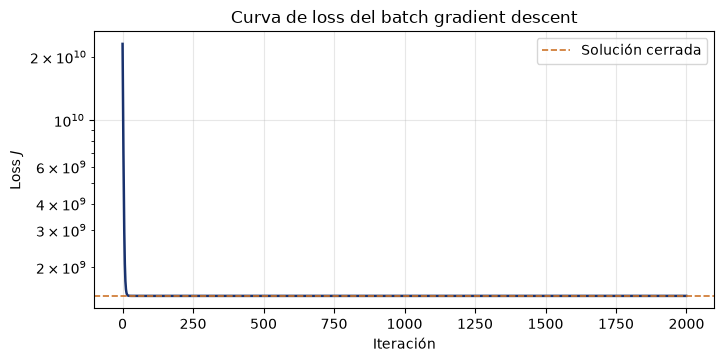

In [14]:
# VERIFICACIÓN — el descenso tiene que llegar a la misma solución que las ecuaciones normales
w_gd, hist = batch_gradient_descent(Xs, y, eta=0.1, n_iter=2000)

print(f"loss del gradient descent    = {hist[-1]:,.1f}")
print(f"loss de la solución cerrada  = {mse_loss(Xs, y, w_cerrado_s):,.1f}")
print(f"\nmayor diferencia entre coeficientes: {np.max(np.abs(w_gd - w_cerrado_s)):.3e}")
print("¿np.allclose?", np.allclose(w_gd, w_cerrado_s))

fig, ax = plt.subplots()
ax.plot(hist, color=AZUL, lw=1.8)
ax.axhline(mse_loss(Xs, y, w_cerrado_s), color=NARANJA, ls="--", lw=1.2,
           label="Solución cerrada")
ax.set_yscale("log")
ax.set_xlabel("Iteración")
ax.set_ylabel("Loss $J$")
ax.set_title("Curva de loss del batch gradient descent")
ax.legend()
plt.show()

---

# 3. El learning rate

La cota es $\eta < 2/L$, con $L$ el mayor autovalor de la Hessiana
$\mathbf{H}=\frac{2}{n}\mathbf{X}^\top\mathbf{X}$.

### Ejercicio 4

1. Calcular $L$ y la cota $\eta_{\max}=2/L$ sobre los datos **estandarizados**.
2. Correr el descenso 120 iteraciones para $\eta \in \{0{,}01;\ 0{,}05;\ 0{,}15;\ 0{,}6;\ 1{,}02\}$
   y graficar las cinco curvas de loss en escala logarítmica.
3. Armar un `DataFrame` con el learning rate, la loss final y si superó la cota.

L = 7.185240
Learning rate máximo: 0.278348


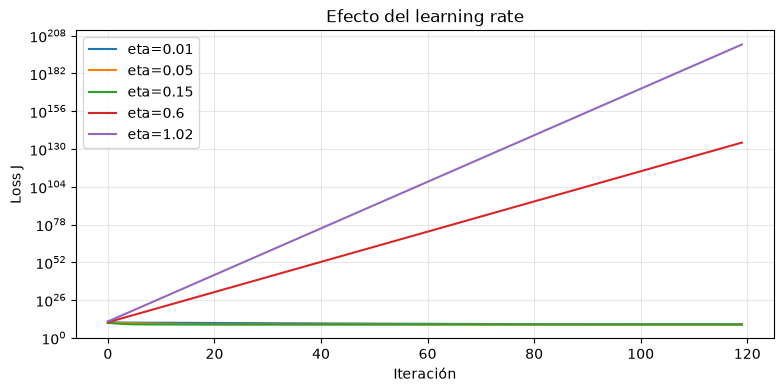

,learning_rate,loss_final,supero_cota
0,0.01,1.732282e+09,False
1,0.05,1.460192e+09,False
2,0.15,1.460173e+09,False
3,0.60,2.768138e+134,True
4,1.02,9.267548e+201,True


In [15]:
H = (2 / n) * (Xs.T @ Xs)
L = np.linalg.eigvalsh(H).max()
eta_max = 2 / L

print(f"L = {L:.6f}")
print(f"Learning rate máximo: {eta_max:.6f}")

learning_rates = [0.01, 0.05, 0.15, 0.6, 1.02]
filas = []

fig, ax = plt.subplots(figsize=(9, 4))

for eta in learning_rates:
    with np.errstate(over="ignore", invalid="ignore"):
        _, historial_eta = batch_gradient_descent(
            Xs,
            y,
            eta=eta,
            n_iter=120,
        )

    ax.plot(
        historial_eta,
        lw=1.5,
        label=f"eta={eta}",
    )

    filas.append({
        "learning_rate": eta,
        "loss_final": historial_eta[-1],
        "supero_cota": eta >= eta_max,
    })

ax.set_yscale("log")
ax.set_xlabel("Iteración")
ax.set_ylabel("Loss J")
ax.set_title("Efecto del learning rate")
ax.legend()
plt.show()

resultados_eta = pd.DataFrame(filas)
resultados_eta

### DECIDE

Sobre lo observado, responder:

1. ¿Cuáles de los cinco learning rates divergieron? ¿Coincide con lo que predice la cota
   $2/L$?
2. Entre los que convergen, ¿el más chico es el mejor? Justificar con la curva.
3. Un compañero informa que su gradient descent «no converge» y que va a correrlo con diez
   veces más iteraciones. ¿Qué corresponde revisar antes?

**Respuesta:**

Los learning rates que superan la cota 2/L divergen, lo cual coincide con la predicción teórica. Entre los que convergen, el más chico no es necesariamente el mejor porque avanza muy lentamente. Una tasa adecuada llega al mínimo en menos iteraciones. Antes de aumentar la cantidad de iteraciones hay que revisar la curva de loss, el learning rate y el escalado. Si la tasa supera la cota, agregar iteraciones empeora el resultado.

---

# 4. Feature scaling

Es el experimento central del laboratorio. La pregunta es concreta: **¿cuántas iteraciones
necesita el mismo algoritmo, sobre los mismos datos, con y sin estandarizar?**

### Ejercicio 5

1. Calcular el número de condición $\kappa$ de $\mathbf{X}^\top\mathbf{X}$ en los dos casos,
   con `np.linalg.cond`.
2. Calcular el mayor learning rate admisible en cada caso.
3. Correr 2000 iteraciones en cada caso con el 90 % de su learning rate máximo.
4. Informar, para cada uno, cuántas iteraciones hicieron falta para que
   $J \le 1{,}01\,J^*$, con $J^*$ la loss de la solución cerrada correspondiente.
5. Graficar las dos curvas de loss en el mismo par de ejes.

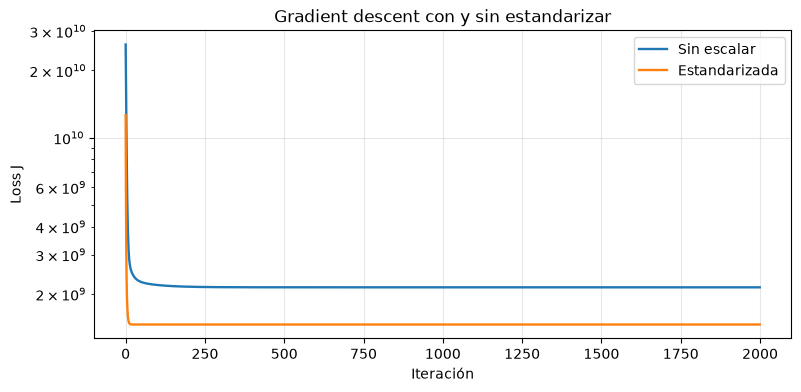

,versión,kappa,eta_max,eta_usada,J_star,J_final,J_final / J_star,iteraciones_hasta_1%
0,Sin escalar,5.518235e+10,1.296970e-07,1.167273e-07,1.460173e+09,2.141264e+09,1.466445,NaN
1,Estandarizada,3.277522e+01,2.783484e-01,2.505135e-01,1.460173e+09,1.460173e+09,1.000000,13.0


In [16]:
versiones = {
    "Sin escalar": X,
    "Estandarizada": Xs,
}

filas = []
historiales_escalado = {}

fig, ax = plt.subplots(figsize=(9, 4))

for nombre, X_version in versiones.items():
    XtX = X_version.T @ X_version
    kappa = np.linalg.cond(XtX)

    H_version = (2 / len(y)) * XtX
    L_version = np.linalg.eigvalsh(H_version).max()
    eta_max_version = 2 / L_version
    eta_version = 0.9 * eta_max_version

    w_star = np.linalg.solve(XtX, X_version.T @ y)
    J_star = mse_loss(X_version, y, w_star)

    _, historial = batch_gradient_descent(
        X_version,
        y,
        eta=eta_version,
        n_iter=2000,
    )

    historiales_escalado[nombre] = historial

    indices = np.where(historial <= 1.01 * J_star)[0]
    iteraciones_1pct = int(indices[0] + 1) if len(indices) else None

    filas.append({
        "versión": nombre,
        "kappa": kappa,
        "eta_max": eta_max_version,
        "eta_usada": eta_version,
        "J_star": J_star,
        "J_final": historial[-1],
        "J_final / J_star": historial[-1] / J_star,
        "iteraciones_hasta_1%": iteraciones_1pct,
    })

    ax.plot(
        historial,
        lw=1.7,
        label=nombre,
    )

comparacion_escalado = pd.DataFrame(filas)

ax.set_yscale("log")
ax.set_xlabel("Iteración")
ax.set_ylabel("Loss J")
ax.set_title("Gradient descent con y sin estandarizar")
ax.legend()
plt.show()

comparacion_escalado

### Para analizar

1. ¿Cuántas veces más grande es $\kappa$ sin escalar?
2. La versión sin escalar, tras 2000 iteraciones, ¿a qué distancia relativa quedó del óptimo?
3. **Mirando únicamente su curva de loss**, ¿habría alguna forma de darse cuenta de que ese
   modelo está mal ajustado? Es la pregunta más importante del laboratorio.

**Respuesta:**

El número de condición es mucho mayor sin escalar, por lo que la superficie tiene forma de valle largo y angosto. Incluso usando una tasa cercana a la máxima admisible, la versión sin escalar no alcanza el óptimo en 2000 iteraciones. Su curva baja de manera estable, así que mirándola de forma aislada podría parecer que el entrenamiento funciona. Para detectar el problema hay que compararla con una referencia, revisar el número de condición o probar el escalado.

---

# 5. SGD y mini-batches

Las tres variantes son el mismo algoritmo con distinto **batch size** $B$: $B=n$ es batch
gradient descent, $B=1$ es **SGD** (*stochastic gradient descent*), y $1<B<n$ son
mini-batches. Una **epoch** es una pasada completa por las $n$ observaciones.

### Ejercicio 6

Implementar una única función parametrizada por el batch size. En cada epoch, los índices
se permutan antes de partirlos.

In [17]:
def minibatch_gradient_descent(X, y, eta=0.01, n_epochs=10, B=32, semilla=0,gradient=mse_gradient, loss=mse_loss):
    rng = np.random.default_rng(semilla)
    w = np.zeros(X.shape[1])
    loss_por_epoch = []

    n_observaciones = len(y)

    for _ in range(n_epochs):
        indices = rng.permutation(n_observaciones)

        for inicio in range(0, n_observaciones, B):
            indices_batch = indices[inicio:inicio + B]

            X_batch = X[indices_batch]
            y_batch = y[indices_batch]

            g = gradient(X_batch, y_batch, w)
            w = w - eta * g

        loss_por_epoch.append(loss(X, y, w))

    return w, np.array(loss_por_epoch)


In [18]:
# VERIFICACIÓN — con B = n tiene que dar exactamente lo mismo que batch_gradient_descent
w_a, _ = batch_gradient_descent(Xs, y, eta=0.05, n_iter=5)
w_b, _ = minibatch_gradient_descent(Xs, y, eta=0.05, n_epochs=5, B=n)
print("¿Coinciden con B = n?", np.allclose(w_a, w_b))

¿Coinciden con B = n? True


Batch (B = n)          eta=0.05   J final =    4,141,759,227.7   actualizaciones = 12
Mini-batch (B = 32)    eta=0.05   J final =    1,464,208,897.4   actualizaciones = 552
SGD (B = 1)            eta=0.005  J final =    1,554,856,537.2   actualizaciones = 17,520

Óptimo                              J*      =    1,460,173,099.5


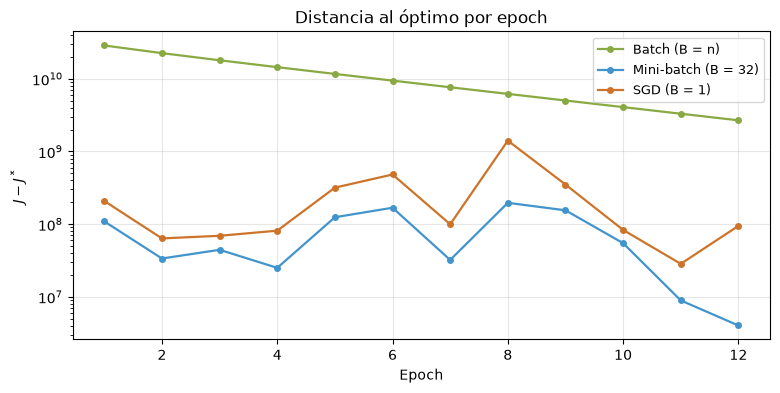

In [19]:
# Comparación de las tres variantes con el mismo presupuesto de epochs
EPOCHS = 12
resultados = {}
for etiqueta, B, eta in [("Batch (B = n)", n, 0.05),
                         ("Mini-batch (B = 32)", 32, 0.05),
                         ("SGD (B = 1)", 1, 0.005)]:
    _, losses = minibatch_gradient_descent(Xs, y, eta=eta, n_epochs=EPOCHS, B=B,
                                           semilla=7)
    resultados[etiqueta] = losses
    actualizaciones = EPOCHS * int(np.ceil(n / B))
    print(f"{etiqueta:22s} eta={eta:<6} J final = {losses[-1]:>18,.1f}"
          f"   actualizaciones = {actualizaciones:,}")

print(f"\n{'Óptimo':22s} {'':12} J*      = {mse_loss(Xs, y, w_cerrado_s):>18,.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
for (etiqueta, c), color in zip(resultados.items(), [OLIVA, AZUL_CLARO, NARANJA]):
    ax.plot(range(1, EPOCHS + 1), c - mse_loss(Xs, y, w_cerrado_s), "-o",
            color=color, ms=4, lw=1.6, label=etiqueta)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("$J - J^*$")
ax.set_title("Distancia al óptimo por epoch")
ax.legend(fontsize=9)
plt.show()

### Para analizar

1. Con el mismo presupuesto de epochs —es decir, con el mismo cómputo—, ¿cuál avanza más?
2. ¿Cuántas veces actualiza sus parámetros cada variante en una sola epoch?
3. SGD deja de mejorar antes de llegar al óptimo. **¿Por qué?** Pensar qué vale el gradiente
   de una observación individual cuando el gradiente completo ya es cero.

**Respuesta:**

SGD y mini-batch avanzan más rápido por época porque actualizan los parámetros varias veces durante cada pasada. Batch actualiza una vez, mini-batch aproximadamente ceil(n/32) veces y SGD n veces. SGD deja de mejorar exactamente porque, aunque el gradiente completo sea cero cerca del óptimo, los gradientes individuales no lo son. Con una tasa constante continúa fluctuando alrededor del mínimo.

---

# 6. La biblioteca hace exactamente esto

`SGDRegressor` de `scikit-learn` implementa stochastic gradient descent. Sus argumentos son
los de este laboratorio con otros nombres: `eta0` es el learning rate inicial, `max_iter`
son las epochs, `learning_rate` es la programación del learning rate y `tol` es el criterio
de parada.

### Ejercicio 7

1. Ajustar un `SGDRegressor` sobre los datos **estandarizados**, sin penalización
   (`penalty=None`), con `learning_rate="constant"`, `eta0=0.01`, `max_iter=2000`,
   `tol=1e-6` y `random_state=0`.
2. Comparar su RMSE con el de la implementación propia y con el de la solución cerrada.
3. Repetir el ajuste sobre los datos **sin estandarizar** y observar qué ocurre.

In [20]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=2000,
    tol=1e-6,
    random_state=0,
)

sgd.fit(Xs[:, 1:], y)

w_sgd = np.concatenate([sgd.intercept_, sgd.coef_])

pred_sgd = Xs @ w_sgd
pred_propia = Xs @ w_gd
pred_cerrada = Xs @ w_cerrado_s

rmse_sgd = np.sqrt(np.mean((pred_sgd - y) ** 2))
rmse_propia = np.sqrt(np.mean((pred_propia - y) ** 2))
rmse_cerrada = np.sqrt(np.mean((pred_cerrada - y) ** 2))

print(f"RMSE SGDRegressor:       {rmse_sgd:,.2f}")
print(f"RMSE implementación:     {rmse_propia:,.2f}")
print(f"RMSE solución cerrada:   {rmse_cerrada:,.2f}")

# Repetición sin estandarizar
sgd_sin_escalar = SGDRegressor(
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=2000,
    tol=1e-6,
    random_state=0,
)

with np.errstate(over="ignore", invalid="ignore"):
    sgd_sin_escalar.fit(X[:, 1:], y)
    pred_sin_escalar = sgd_sin_escalar.predict(X[:, 1:])
    rmse_sin_escalar = np.sqrt(
        np.mean((pred_sin_escalar - y) ** 2)
    )

print(f"\nRMSE sin estandarizar:   {rmse_sin_escalar:,.2f}")

RMSE SGDRegressor:       39,299.95
RMSE implementación:     38,212.21
RMSE solución cerrada:   38,212.21

RMSE sin estandarizar:   41,004,940,157,344,936.00


### Para analizar

1. Sobre los datos estandarizados, `SGDRegressor` no alcanza exactamente el RMSE de la
   solución cerrada: queda algunos puntos porcentuales por encima. **¿Por qué?** Relacionarlo
   con lo observado en la sección 5.
2. ¿Qué le ocurrió a `SGDRegressor` sobre los datos sin estandarizar?
3. La documentación de `scikit-learn` advierte que este estimador «es sensible al feature
   scaling». Con lo medido en este laboratorio, **¿qué significa exactamente esa
   advertencia?**

**Respuesta:**

SGDRegressor no llega exactamente al RMSE óptimo porque utiliza gradientes de observaciones individuales y una tasa constante. Cerca del mínimo continúa fluctuando. Sin estandarizar, las diferencias de escala generan gradientes demasiado distintos y el ajuste se vuelve inestable o diverge. Decir que el estimador es sensible al feature scaling significa que su convergencia y estabilidad dependen fuertemente de que las variables tengan escalas comparables.

---

# 7. El mismo motor: logistic regression

Hasta acá el gradient descent resolvió un problema que **ya tenía solución cerrada**: servía
para verificar la implementación, no porque hiciera falta. La logistic regression es el caso
en que sí hace falta, porque el sistema
$\mathbf{X}^\top(\boldsymbol\sigma(\mathbf{X}\mathbf{w})-\mathbf{y})=\mathbf{0}$
**no se despeja**.

Lo que cambia es **una sola función**: el gradiente. El bucle escrito en el ejercicio 3 se
reutiliza sin tocar una línea.

Los datos son las 4000 solicitudes de crédito del tratamiento de logistic regression. La
clase positiva es el incumplimiento.

In [22]:
#@title Carga y matriz de diseño de las solicitudes (ejecutar sin modificar) { display-mode: "form" }

archivo_credito = (
    "https://raw.githubusercontent.com/"
    "gustavovazquez/datasets/refs/heads/main/riesgo_credito.csv"
)
credito = pd.read_csv(archivo_credito)
tabla = credito.copy()
tabla["hist_atrasos"] = (tabla["historial_crediticio"] == "con atrasos").astype(int)
tabla["hist_sin"] = (tabla["historial_crediticio"] == "sin historial").astype(int)
tabla["log_monto"] = np.log(tabla["monto_solicitado_usd"]) - np.log(10_000)
tabla["edad_c"] = tabla["edad_anios"] - 38

FEATURES_C = ["cuota_ingreso", "hist_atrasos", "hist_sin", "consultas_buro_12m",
              "antiguedad_laboral_anios", "tiene_garantia", "edad_c", "log_monto"]

Xc = con_intercepto(tabla[FEATURES_C].to_numpy(dtype=float))
yc = tabla["incumplio"].to_numpy(dtype=float)
Xcs, mu_c, sigma_c = standardize(Xc)
n_c = len(yc)

print(f"Xc: {Xc.shape}   yc: {yc.shape}")
print(f"Positivos: {int(yc.sum())} de {n_c}  ({yc.mean():.1%})")
print("desvíos de las features:", sigma_c.round(3))

Xc: (4000, 9)   yc: (4000,)
Positivos: 873 de 4000  (21.8%)
desvíos de las features: [ 0.164  0.406  0.456  1.425  3.518  0.471 10.393  0.712]


La función logística ya es conocida y se entrega implementada, con el recorte que evita
el desborde de `np.exp`.

$$
\sigma(z)=\frac{1}{1+e^{-z}},
\qquad
J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^n\bigl[y_i\log \hat p_i+(1-y_i)\log(1-\hat p_i)\bigr],
\qquad
\nabla J(\mathbf{w}) = \frac{1}{n}\,\mathbf{X}^\top(\boldsymbol\sigma-\mathbf{y})
$$

### Ejercicio 8

Implementar la **cross-entropy loss** y su gradiente, con las dos firmas
`(X, y, w)` —las mismas que `mse_loss` y `mse_gradient`, que es lo que permite pasarlas al
motor ya escrito.

**Cuidado con $\log(0)$:** si alguna probabilidad estimada llega a 0 o a 1 por redondeo, el
logaritmo devuelve `-inf`. Recortar las probabilidades a $[\varepsilon,\,1-\varepsilon]$
con $\varepsilon=10^{-12}$ es la solución habitual.

In [23]:
#@title La función logística (ejecutar sin modificar) { display-mode: "form" }
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Función logística, componente a componente, sin desborde."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

In [24]:
def logistic_loss(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
) -> float:
    """Cross-entropy loss promedio."""

    probabilidades = sigmoid(X @ w)
    epsilon = 1e-12

    probabilidades = np.clip(
        probabilidades,
        epsilon,
        1 - epsilon,
    )

    perdida = -np.mean(
        y * np.log(probabilidades)
        + (1 - y) * np.log(1 - probabilidades)
    )

    return float(perdida)


def logistic_gradient(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Gradiente de la cross-entropy loss."""

    probabilidades = sigmoid(X @ w)
    return (1 / len(y)) * (X.T @ (probabilidades - y))

In [25]:
# VERIFICACIÓN — la loss contra log_loss de scikit-learn, y el gradiente contra
# diferencias finitas. Se reutiliza la misma gradiente_numerico del ejercicio 2.
from sklearn.metrics import log_loss

rng = np.random.default_rng(0)
w_prueba_c = rng.normal(0, 0.3, Xcs.shape[1])
p_prueba = sigmoid(Xcs @ w_prueba_c)

print(f"logistic_loss propia : {logistic_loss(Xcs, yc, w_prueba_c):.8f}")
print(f"log_loss scikit-learn: {log_loss(yc, p_prueba):.8f}")
assert np.isclose(logistic_loss(Xcs, yc, w_prueba_c), log_loss(yc, p_prueba))

g_a = logistic_gradient(Xcs, yc, w_prueba_c)
g_n = gradiente_numerico(logistic_loss, Xcs, yc, w_prueba_c, h=1e-5)
print("\nanalítico:", g_a)
print("numérico :", g_n)
print("\n¿Coinciden?", np.allclose(g_a, g_n, rtol=1e-5, atol=1e-8))

tasa_base = yc.mean()
w_base = np.zeros(Xcs.shape[1])
w_base[0] = np.log(tasa_base / (1 - tasa_base))
print(f"\nLoss de predecir la tasa base a todos: {logistic_loss(Xcs, yc, w_base):.4f}")
print("Cualquier modelo útil tiene que quedar por debajo de ese valor.")

logistic_loss propia : 0.80455155
log_loss scikit-learn: 0.80455155

analítico: [ 0.2898 -0.2329 -0.0296 -0.0337 -0.1357  0.0665  0.1276  0.0839 -0.156 ]
numérico : [ 0.2898 -0.2329 -0.0296 -0.0337 -0.1357  0.0665  0.1276  0.0839 -0.156 ]

¿Coinciden? True

Loss de predecir la tasa base a todos: 0.5247
Cualquier modelo útil tiene que quedar por debajo de ese valor.


### Ejercicio 9

Ajustar la logistic regression **sin escribir un bucle nuevo**: llamar a
`batch_gradient_descent` pasándole `gradient=logistic_gradient` y `loss=logistic_loss`.

1. Ajustar sobre `Xcs` (estandarizado) con $\eta=0{,}5$ y 4000 iteraciones, y verificar
   contra `LogisticRegression(C=np.inf, max_iter=5000, tol=1e-10)`. **Desactivar la
   regularización es obligatorio**: por omisión el estimador regulariza, y entonces sus
   coeficientes no son los de máxima verosimilitud y la comparación no cierra. `C` es la
   inversa de la intensidad de la penalización, de modo que $C=\infty$ la anula.
2. Ajustar también con `minibatch_gradient_descent`, con $B=64$ y 30 epochs, y comparar la
   loss alcanzada.
3. Repetir el ajuste del punto 1 **sobre `Xc` sin estandarizar, con el mismo $\eta$**, y
   comparar la loss final. Es el experimento de la sección 4 sobre otro modelo.
4. Graficar las dos curvas de loss del punto 3 en el mismo par de ejes.

Loss batch propia: 0.391229
Loss scikit-learn: 0.391229
¿Coeficientes cercanos? True
Mayor diferencia: 6.200407354217674e-09

Loss mini-batch: 0.391895
Loss batch:      0.391229

Loss estandarizada: 0.391229
Loss sin escalar:   1.365609
Loss tasa base:      0.524684


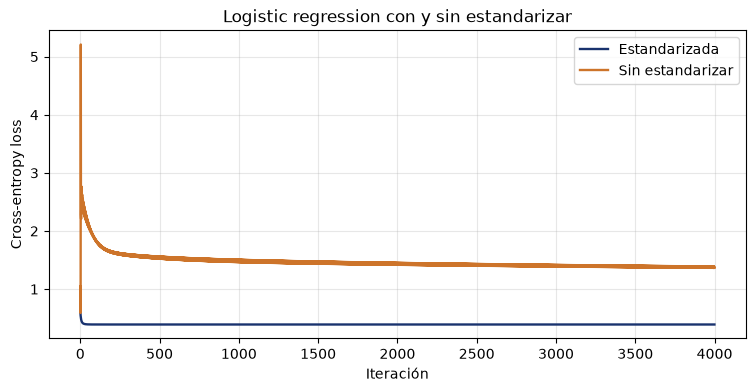

In [26]:
from sklearn.linear_model import LogisticRegression

# Batch gradient descent sobre datos estandarizados
w_log, hist_log = batch_gradient_descent(
    Xcs,
    yc,
    eta=0.5,
    n_iter=4000,
    gradient=logistic_gradient,
    loss=logistic_loss,
)

print(f"Loss batch propia: {hist_log[-1]:.6f}")

# LogisticRegression sin regularización
modelo_sk = LogisticRegression(
    C=np.inf,
    max_iter=5000,
    tol=1e-10,
)

modelo_sk.fit(Xcs[:, 1:], yc)

w_sk = np.concatenate([
    modelo_sk.intercept_,
    modelo_sk.coef_.ravel(),
])

print(f"Loss scikit-learn: {logistic_loss(Xcs, yc, w_sk):.6f}")
print(
    "¿Coeficientes cercanos?",
    np.allclose(w_log, w_sk, rtol=1e-3, atol=1e-3),
)

print(
    "Mayor diferencia:",
    np.max(np.abs(w_log - w_sk)),
)

# Mini-batch
w_log_mb, hist_log_mb = minibatch_gradient_descent(
    Xcs,
    yc,
    eta=0.5,
    n_epochs=30,
    B=64,
    semilla=0,
    gradient=logistic_gradient,
    loss=logistic_loss,
)

print(f"\nLoss mini-batch: {hist_log_mb[-1]:.6f}")
print(f"Loss batch:      {hist_log[-1]:.6f}")

# Batch sin estandarizar, usando la misma tasa
w_log_crudo, hist_log_crudo = batch_gradient_descent(
    Xc,
    yc,
    eta=0.5,
    n_iter=4000,
    gradient=logistic_gradient,
    loss=logistic_loss,
)

print(f"\nLoss estandarizada: {hist_log[-1]:.6f}")
print(f"Loss sin escalar:   {hist_log_crudo[-1]:.6f}")
print(f"Loss tasa base:      {logistic_loss(Xcs, yc, w_base):.6f}")

# Comparación de curvas
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(
    hist_log,
    color=AZUL,
    lw=1.7,
    label="Estandarizada",
)

ax.plot(
    hist_log_crudo,
    color=NARANJA,
    lw=1.7,
    label="Sin estandarizar",
)

ax.set_xlabel("Iteración")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Logistic regression con y sin estandarizar")
ax.legend()
plt.show()

### Para analizar

1. El bucle del ejercicio 3 se escribió para una linear regression y ajustó una logistic
   regression sin ninguna modificación. **¿Qué tiene que cumplir un modelo para poder
   ajustarse con este motor?**
2. La cota $\eta<2/L$ de la sección 3 se calculó con la Hessiana de la loss cuadrática,
   que **no depende de $\mathbf{w}$**. La Hessiana de la cross-entropy sí depende de
   $\mathbf{w}$. ¿Qué consecuencia tiene eso sobre la posibilidad de elegir el learning
   rate de antemano, como se hizo en el ejercicio 4?
3. `LogisticRegression` usa L-BFGS y converge en **decenas** de iteraciones, contra las 4000
   de este laboratorio. Con lo visto en la sección 3, ¿qué información usa L-BFGS que el
   gradient descent con learning rate constante no usa?
4. Sin estandarizar, la loss quedó por encima de la de predecir la tasa base a todos.
   ¿Qué habría concluido alguien que solo mirara los coeficientes ajustados?

**Respuesta:**

El mismo motor puede ajustar cualquier modelo cuya función de pérdida sea diferenciable y para el cual podamos calcular un gradiente compatible. En logistic regression solamente cambiamos la loss y el gradiente. A diferencia de la pérdida cuadrática, su Hessiana depende de los parámetros, por lo que no existe una única curvatura constante que permita determinar exactamente la mejor tasa antes de entrenar. L-BFGS utiliza información aproximada de segundo orden, es decir, de la curvatura, y por eso converge en muchas menos iteraciones. Sin estandarizar, los parámetros obtenidos pueden parecer resultados válidos aunque el modelo tenga una loss peor que predecir siempre la tasa base.

---

## Cierre

- **El gradient descent encuentra la misma solución que las ecuaciones normales**, y la
  verificación con `np.allclose` es lo único que distingue una implementación correcta de una
  que converge a otro lado.
- **El learning rate tiene una cota**, $\eta < 2/L$, y superarla no se arregla con más
  iteraciones.
- **El feature scaling decide si el método converge.** El mismo algoritmo sobre los mismos
  datos necesita menos de veinte iteraciones estandarizado y no llega en dos mil sin
  estandarizar, sin que la curva de loss exhiba ningún síntoma.
- **Las tres variantes son un solo algoritmo** parametrizado por el batch size $B$.
- **El motor no depende del modelo.** Un bucle escrito para una linear regression ajusta una
  logistic regression cambiando la función de gradiente, y es por eso que el mismo método
  sirve para las redes neuronales, donde ninguna solución cerrada existe.

## Para seguir explorando

Sin obligación y fuera del tiempo de clase:

1. **Learning rate schedule.** Modificar `minibatch_gradient_descent` para que use
   $\eta_t = \eta_0/(1+\gamma t)$ y verificar si SGD deja de fluctuar.
2. **El punto inicial.** Repetir el descenso desde varios puntos iniciales aleatorios y
   comprobar que todos llegan al mismo lugar. ¿Qué propiedad de la loss lo garantiza?
3. **Momentum.** Agregar $\mathbf{v}^{(t)} = \beta\mathbf{v}^{(t-1)} + \nabla J$ y actualizar
   con $\mathbf{v}$ en lugar del gradiente. Comparar la cantidad de iteraciones necesarias
   sobre los datos **sin** estandarizar.
4. **`SGDClassifier`.** Ajustar `SGDClassifier(loss="log_loss", penalty=None)` sobre las
   solicitudes de crédito y comparar contra el ajuste propio del ejercicio 9.


In [27]:
def minibatch_gd_schedule(
    X,
    y,
    eta0=0.01,
    gamma=0.001,
    n_epochs=20,
    B=32,
    semilla=0,
    gradient=mse_gradient,
    loss=mse_loss,
):
    rng = np.random.default_rng(semilla)
    w = np.zeros(X.shape[1])
    historial = []

    n = len(y)
    t = 0

    for _ in range(n_epochs):
        indices = rng.permutation(n)

        for inicio in range(0, n, B):
            idx = indices[inicio:inicio + B]

            eta_t = eta0 / (1 + gamma * t)
            g = gradient(X[idx], y[idx], w)
            w = w - eta_t * g

            t += 1

        historial.append(loss(X, y, w))

    return w, np.array(historial)

**Respuesta**

Con una tasa constante, SGD fluctúa alrededor del óptimo porque los gradientes individuales no se anulan. Al reducir la tasa con las actualizaciones, las oscilaciones disminuyen y los parámetros pueden acercarse más al mínimo.

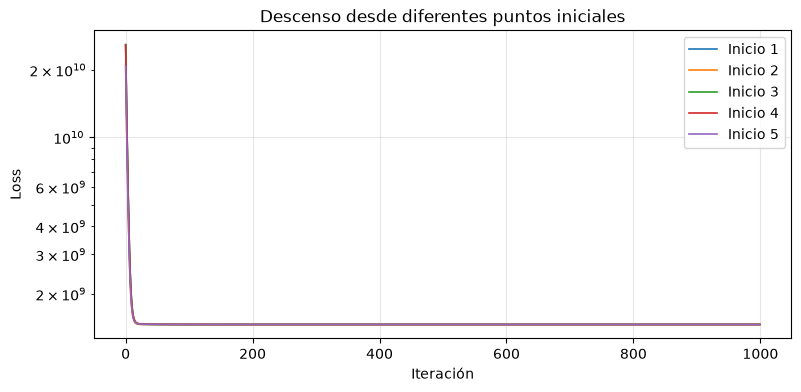

,inicio,loss_final,distancia_a_solucion
0,1,1.460173e+09,1.467783e-06
1,2,1.460173e+09,5.275695e-07
2,3,1.460173e+09,2.541539e-06
3,4,1.460173e+09,3.195342e-06
4,5,1.460173e+09,2.900830e-06


In [28]:
rng = np.random.default_rng(10)

resultados_inicializacion = []

fig, ax = plt.subplots(figsize=(9, 4))

for numero in range(5):
    w_inicial = rng.normal(
        loc=0,
        scale=10_000,
        size=Xs.shape[1],
    )

    w_final, historial = batch_gradient_descent(
        Xs,
        y,
        eta=0.1,
        n_iter=1000,
        w0=w_inicial,
    )

    resultados_inicializacion.append({
        "inicio": numero + 1,
        "loss_final": historial[-1],
        "distancia_a_solucion": np.linalg.norm(
            w_final - w_cerrado_s
        ),
    })

    ax.plot(
        historial,
        lw=1.2,
        label=f"Inicio {numero + 1}",
    )

ax.set_yscale("log")
ax.set_xlabel("Iteración")
ax.set_ylabel("Loss")
ax.set_title("Descenso desde diferentes puntos iniciales")
ax.legend()
plt.show()

pd.DataFrame(resultados_inicializacion)

**Respuesta**

Todos los puntos iniciales llegan prácticamente al mismo resultado porque la función de costo cuadrática es convexa. En una función convexa, todo mínimo local es global. El punto inicial puede cambiar el recorrido y la cantidad de iteraciones, pero no el mínimo final.

In [29]:
def gradient_descent_momentum(
    X,
    y,
    eta=0.01,
    beta=0.9,
    n_iter=1000,
    w0=None,
    gradient=mse_gradient,
    loss=mse_loss,
):
    if w0 is None:
        w = np.zeros(X.shape[1])
    else:
        w = np.array(w0, dtype=float, copy=True)

    velocidad = np.zeros_like(w)
    historial = []

    for _ in range(n_iter):
        g = gradient(X, y, w)

        velocidad = beta * velocidad + g
        w = w - eta * velocidad

        historial.append(loss(X, y, w))

    return w, np.array(historial)

**Respuesta**

Momentum conserva parte de los gradientes anteriores. Esto acumula velocidad en la dirección estable y reduce las oscilaciones transversales. Puede necesitar menos iteraciones, aunque no reemplaza el escalado.

In [30]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

clasificador_sgd = SGDClassifier(
    loss="log_loss",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    max_iter=2000,
    tol=1e-6,
    random_state=0,
)

clasificador_sgd.fit(Xcs[:, 1:], yc)

probabilidades_sgd = clasificador_sgd.predict_proba(
    Xcs[:, 1:]
)[:, 1]

loss_sgd_classifier = log_loss(
    yc,
    probabilidades_sgd,
)

probabilidades_propias = sigmoid(Xcs @ w_log)

loss_modelo_propio = log_loss(
    yc,
    probabilidades_propias,
)

probabilidades_sklearn = modelo_sk.predict_proba(
    Xcs[:, 1:]
)[:, 1]

loss_logistic_regression = log_loss(
    yc,
    probabilidades_sklearn,
)

print(f"SGDClassifier:         {loss_sgd_classifier:.6f}")
print(f"Implementación propia: {loss_modelo_propio:.6f}")
print(f"LogisticRegression:    {loss_logistic_regression:.6f}")

SGDClassifier:         0.392197
Implementación propia: 0.391229
LogisticRegression:    0.391229


**Respuesta**

SGDClassifier utiliza el mismo principio de gradientes estocásticos, pero con la pérdida logística. Puede quedar cerca del ajuste propio, aunque no necesariamente coincide exactamente porque utiliza actualizaciones individuales y una tasa constante. LogisticRegression, que utiliza un método como L-BFGS, suele acercarse más rápidamente al óptimo.